# Crime Rate Prediction
CS-UY 4563 Final Project | Tyler Huynh and Martha McQuillan


---
# Part 0: Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, pairwise_distances

url = "https://raw.githubusercontent.com/vbordalo/Communities-Crime/master/communities.data"
df = pd.read_csv(url, header=None, na_values=["?"])
print(f"Raw dataset: {df.shape}")
df.head()

Raw dataset: (1994, 128)


,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,8,NaN,NaN,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,NaN,NaN,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,NaN,NaN,NaN,NaN,0.00,NaN,0.67
2,24,NaN,NaN,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.43
3,34,5.0,81440.0,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,NaN,NaN,NaN,NaN,0.00,NaN,0.12
4,42,95.0,6096.0,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.03


In [2]:
df_model = df.copy()

# Drop ID columns (first 5 columns)
df_model = df_model.drop(columns=[0,1,2,3,4])

df_model.head()

,5,6,7,8,9,10,11,12,13,14,...,118,119,120,121,122,123,124,125,126,127
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,...,0.02,0.12,0.45,NaN,NaN,NaN,NaN,0.00,NaN,0.67
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,...,0.01,0.21,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.43
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,...,0.02,0.39,0.28,NaN,NaN,NaN,NaN,0.00,NaN,0.12
4,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,0.36,...,0.04,0.09,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.03


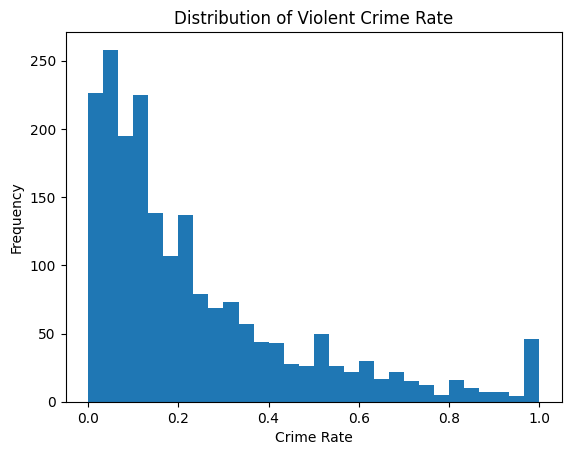

In [3]:
target = df_model.columns[-1]  # last column is target

plt.hist(df_model[target].dropna(), bins=30)
plt.title("Distribution of Violent Crime Rate")
plt.xlabel("Crime Rate")
plt.ylabel("Frequency")
plt.savefig("target_distribution.png")
plt.show()

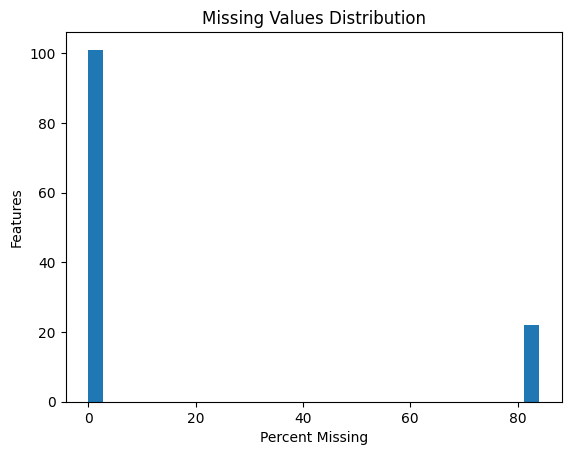

In [4]:
missing_pct = df_model.isna().mean() * 100

plt.hist(missing_pct, bins=30)
plt.title("Missing Values Distribution")
plt.xlabel("Percent Missing")
plt.ylabel("Features")
plt.savefig("missing_values.png")
plt.show()

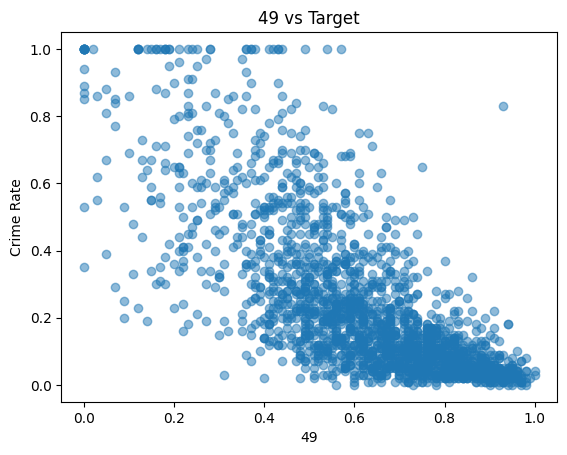

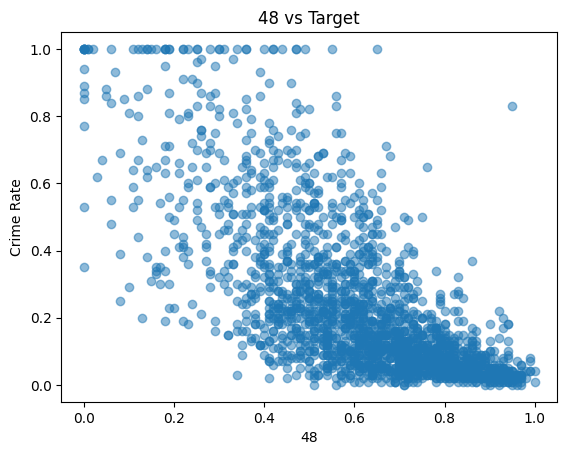

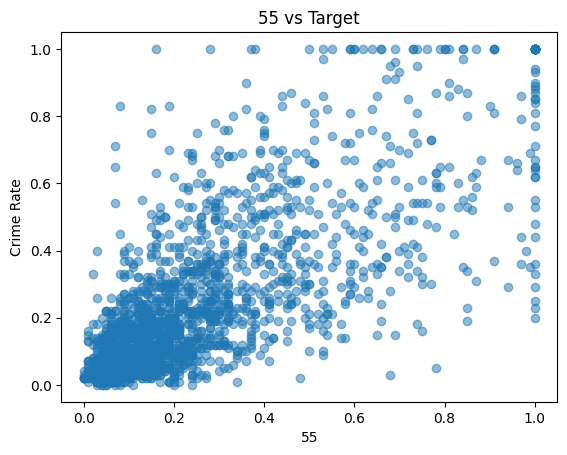

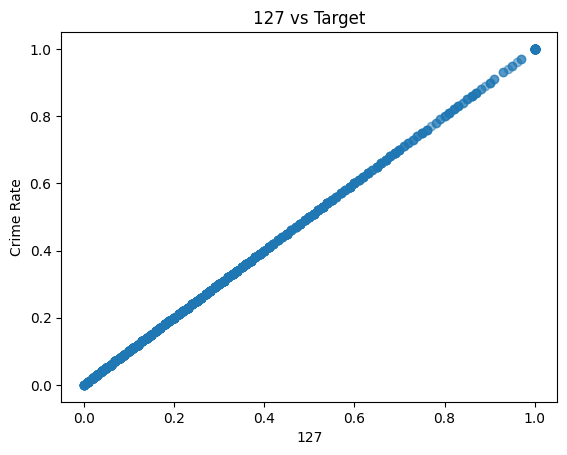

In [5]:
corr = df_model.corr(numeric_only=True)[target].sort_values()

features = list(corr.head(2).index) + list(corr.tail(2).index)

for col in features:
    plt.scatter(df_model[col], df_model[target], alpha=0.5)
    plt.title(f"{col} vs Target")
    plt.xlabel(col)
    plt.ylabel("Crime Rate")
    plt.show()

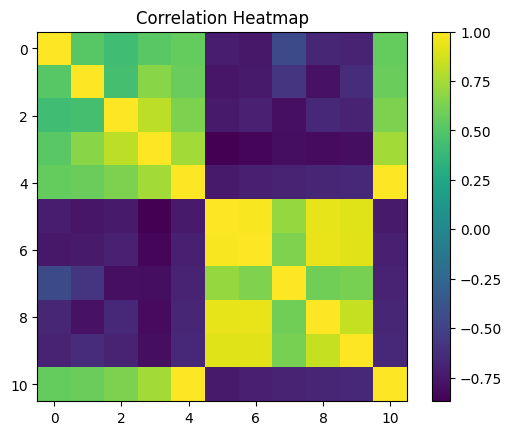

In [6]:
top_features = list(corr.tail(5).index) + list(corr.head(5).index)
top_features.append(target)

corr_matrix = df_model[top_features].corr()

plt.imshow(corr_matrix)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()

Drop columns with >50% missing values

In [7]:
# Drop features with more than 50% missing values
high_missing = missing_pct[missing_pct > 50].index
print(f"Dropping {len(high_missing)} high-missing columns: {list(high_missing)}")

df_model = df_model.drop(columns=high_missing)
print(f"Shape after dropping: {df_model.shape}")

Dropping 22 high-missing columns: [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 121, 122, 123, 124, 126]
Shape after dropping: (1994, 101)


Separate features and target, remove rows with missing target

In [8]:
# target variable was assigned above as df_model.columns[-1]
X = df_model.drop(columns=[target])
y = df_model[target]

# Remove rows where target is missing
mask = y.notna()
X = X[mask].reset_index(drop=True)
y = y[mask].reset_index(drop=True)

print(f"Features: {X.shape}")
print(f"Target:   {y.shape}")
print(f"Target missing values: {y.isna().sum()}")

Features: (1994, 100)
Target:   (1994,)
Target missing values: 0


Train / Validation / Test split

In [9]:
# 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

Train: 1395 samples
Val:   299 samples
Test:  300 samples


Impute remaining missing values (fit on train only)

In [10]:
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)  # fit + transform on train
X_val_imp   = imputer.transform(X_val)         # transform only
X_test_imp  = imputer.transform(X_test)        # transform only

print("Missing values remaining:")
print(f"  Train: {np.isnan(X_train_imp).sum()}")
print(f"  Val:   {np.isnan(X_val_imp).sum()}")
print(f"  Test:  {np.isnan(X_test_imp).sum()}")

Missing values remaining:
  Train: 0
  Val:   0
  Test:  0


Standard scaling

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)  # fit + transform on train
X_val_scaled   = scaler.transform(X_val_imp)         # transform only
X_test_scaled  = scaler.transform(X_test_imp)        # transform only

print(f"Final feature matrix shape: {X_train_scaled.shape}")

Final feature matrix shape: (1395, 100)


Log-transform the target
The target is right-skewed. Log-transforming it
makes the distribution more symmetric and typically improves regression performance.

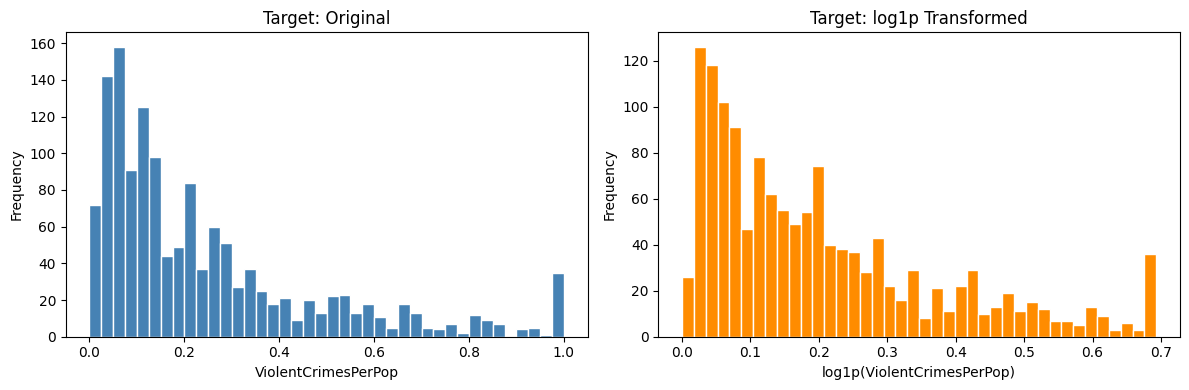

Note: log1p makes the target more symmetric — better for regression models.


In [12]:
y_train_log = np.log1p(y_train.values)
y_val_log   = np.log1p(y_val.values)
y_test_log  = np.log1p(y_test.values)

# Visualize before vs. after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train.values, bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Target: Original")
axes[0].set_xlabel("ViolentCrimesPerPop")
axes[0].set_ylabel("Frequency")

axes[1].hist(y_train_log, bins=40, color="darkorange", edgecolor="white")
axes[1].set_title("Target: log1p Transformed")
axes[1].set_xlabel("log1p(ViolentCrimesPerPop)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("target_log_transform.png", dpi=150)
plt.show()
print("Note: log1p makes the target more symmetric — better for regression models.")

Improved correlation heatmap

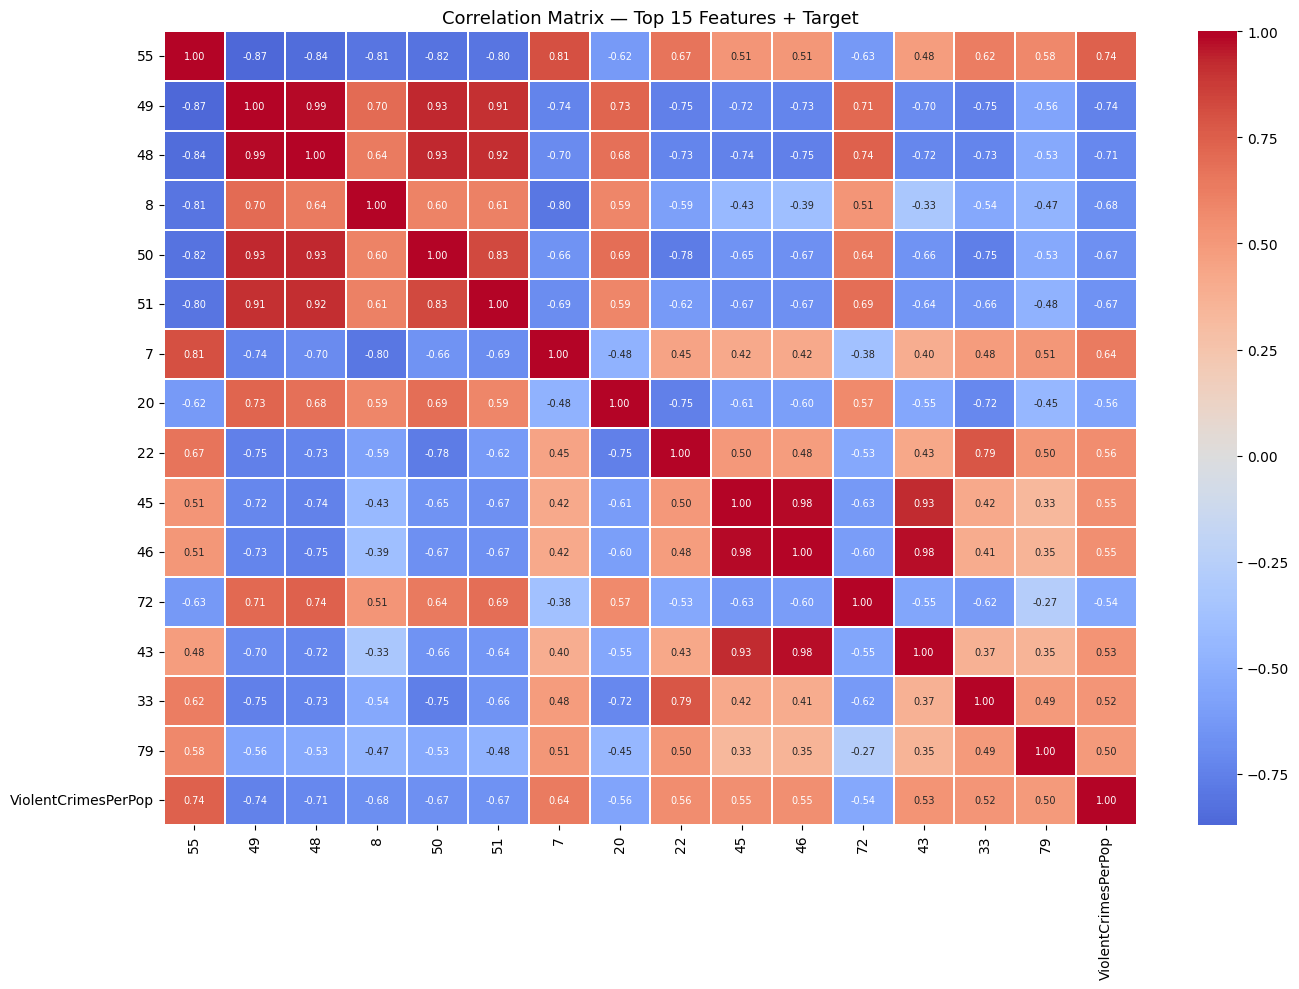


Top 10 features most correlated with ViolentCrimesPerPop:
55    0.739780
49    0.739727
48    0.712523
8     0.677333
50    0.673049
51    0.666004
7     0.640256
20    0.560327
22    0.556623
45    0.553878
Name: ViolentCrimesPerPop, dtype: float64


In [13]:
feature_names = list(X.columns)

# Build a DataFrame from scaled training data to compute correlations
train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
train_df["ViolentCrimesPerPop"] = y_train.values

# Select top 15 features most correlated with target
corr_with_target = train_df.corr()["ViolentCrimesPerPop"].drop("ViolentCrimesPerPop")
top15 = corr_with_target.abs().nlargest(15).index.tolist()
top15.append("ViolentCrimesPerPop")

plt.figure(figsize=(14, 10))
sns.heatmap(
    train_df[top15].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    annot_kws={"size": 7}
)
plt.title("Correlation Matrix — Top 15 Features + Target", fontsize=13)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

print("\nTop 10 features most correlated with ViolentCrimesPerPop:")
print(corr_with_target.abs().nlargest(10))

In [14]:
# Helper function — use this to convert log-scale predictions back to original scale
def inverse_log_transform(y_pred_log):
    """Convert log1p predictions back to original crime rate scale."""
    return np.expm1(y_pred_log)

# Save all splits
np.save("X_train.npy", X_train_scaled)
np.save("X_val.npy",   X_val_scaled)
np.save("X_test.npy",  X_test_scaled)

np.save("y_train.npy",     y_train.values)   # original scale
np.save("y_val.npy",       y_val.values)
np.save("y_test.npy",      y_test.values)

np.save("y_train_log.npy", y_train_log)      # log-transformed
np.save("y_val_log.npy",   y_val_log)
np.save("y_test_log.npy",  y_test_log)

# Save feature names
pd.Series(feature_names).to_csv("feature_names.csv", index=False, header=False)

print("Saved files:")
print("  X_train/val/test.npy      — scaled features")
print("  y_train/val/test.npy      — original target")
print("  y_train/val/test_log.npy  — log1p target (use these for training)")
print("  feature_names.csv         — column names")
print(f"\nFinal dataset: {X_train_scaled.shape[1]} features, {X_train_scaled.shape[0]} train samples")

Saved files:
  X_train/val/test.npy      — scaled features
  y_train/val/test.npy      — original target
  y_train/val/test_log.npy  — log1p target (use these for training)
  feature_names.csv         — column names

Final dataset: 100 features, 1395 train samples


In [15]:
# ── Variable aliases for modeling cells ──────────────────────────────────
# X_train_scaled/X_val_scaled/X_test_scaled = scaled numpy feature arrays
# y_train_log/y_val_log/y_test_log           = log1p numpy arrays (use for training)
# y_train/y_val/y_test                       = original-scale pandas Series (from split)

X_train = X_train_scaled
X_val   = X_val_scaled
X_test  = X_test_scaled

# Store originals before overwriting y_train with log version
y_train_orig = y_train.values  # pandas Series -> numpy, original scale
y_val_orig   = y_val.values
y_test_orig  = y_test.values

# Now overwrite y_train/val/test with log-transformed versions for training
y_train = y_train_log
y_val   = y_val_log
y_test  = y_test_log

def inverse_log(y): return np.expm1(y)

print(f'X_train: {X_train.shape}')
print(f'X_val:   {X_val.shape}')
print(f'X_test:  {X_test.shape}')
print(f'y_train (log1p): min={y_train.min():.3f}, max={y_train.max():.3f}')
print(f'y_train_orig: min={y_train_orig.min():.3f}, max={y_train_orig.max():.3f}')

X_train: (1395, 100)
X_val:   (299, 100)
X_test:  (300, 100)
y_train (log1p): min=0.000, max=0.693
y_train_orig: min=0.000, max=1.000


---
# PART 1: Ridge Regression

### Transformation 1: Polynomial Degree 2
**Reasoning:** EDA scatter plots showed curved nonlinear relationships between
several features (e.g., Feature 48, 49, 55) and ViolentCrimesPerPop. Degree-2
polynomial features add all squared terms (x_i²) and pairwise interactions
(x_i × x_j), allowing Ridge to fit curved relationships in the transformed space.
Re-scaling after transformation is necessary since polynomial terms have much
larger magnitudes than the original features.

In [16]:
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly2 = poly2.fit_transform(X_train)
X_val_poly2   = poly2.transform(X_val)
X_test_poly2  = poly2.transform(X_test)

scaler_p2 = StandardScaler()
X_train_poly2 = scaler_p2.fit_transform(X_train_poly2)
X_val_poly2   = scaler_p2.transform(X_val_poly2)
X_test_poly2  = scaler_p2.transform(X_test_poly2)

print(f"Poly degree-2: {X_train.shape[1]} → {X_train_poly2.shape[1]} features")

Poly degree-2: 100 → 5150 features


### Transformation 2: PCA(20) → Polynomial Degree 3
**Reasoning:** Per the assignment clarification, degree-2 and degree-3 count as
separate transformations. Degree-3 adds cubic interactions for higher model
complexity. Applying degree-3 directly to ~100 features is intractable, so we
first reduce to 20 PCA components. This chained transformation (PCA → poly3)
counts as one transformation per the clarification post. We expect this to
overfit at low lambda and require strong regularization.

In [17]:
pca_pre = PCA(n_components=20, random_state=42)
X_train_pca20 = pca_pre.fit_transform(X_train)
X_val_pca20   = pca_pre.transform(X_val)
X_test_pca20  = pca_pre.transform(X_test)

poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly3 = poly3.fit_transform(X_train_pca20)
X_val_poly3   = poly3.transform(X_val_pca20)
X_test_poly3  = poly3.transform(X_test_pca20)

scaler_p3 = StandardScaler()
X_train_poly3 = scaler_p3.fit_transform(X_train_poly3)
X_val_poly3   = scaler_p3.transform(X_val_poly3)
X_test_poly3  = scaler_p3.transform(X_test_poly3)

print(f"PCA(20) → Poly degree-3: {X_train.shape[1]} → {X_train_poly3.shape[1]} features")

PCA(20) → Poly degree-3: 100 → 1770 features


### Transformation 3: PCA (95% variance)
**Reasoning:** The dataset has strong multicollinearity among socio-economic
variables (income, poverty, employment are all correlated). PCA projects into
orthogonal principal components, eliminating redundant dimensions entirely.
This gives Ridge a compact, decorrelated feature space and we expect better
generalization compared to the polynomial transformations.

In [18]:
pca_ridge = PCA(n_components=0.95, random_state=42)
X_train_pca_r = pca_ridge.fit_transform(X_train)
X_val_pca_r   = pca_ridge.transform(X_val)
X_test_pca_r  = pca_ridge.transform(X_test)

print(f"PCA retained {pca_ridge.n_components_} components (95% variance)")
print(f"Dimensionality: {X_train.shape[1]} → {X_train_pca_r.shape[1]}")

PCA retained 34 components (95% variance)
Dimensionality: 100 → 34


## 1.2 Ridge Training Loop

In [19]:
LAMBDAS = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_feature_spaces = [
    {"name": "No Transformation (baseline)", "short": "no_transform",
     "X_train": X_train,       "X_val": X_val,       "X_test": X_test},
    {"name": "Polynomial Degree 2",           "short": "poly2",
     "X_train": X_train_poly2, "X_val": X_val_poly2, "X_test": X_test_poly2},
    {"name": "PCA(20) + Polynomial Degree 3", "short": "poly3",
     "X_train": X_train_poly3, "X_val": X_val_poly3, "X_test": X_test_poly3},
    {"name": "PCA (95% variance)",            "short": "pca",
     "X_train": X_train_pca_r, "X_val": X_val_pca_r, "X_test": X_test_pca_r},
]

ridge_results  = []
ridge_best_models = {}

for fs in ridge_feature_spaces:
    print(f"\n{'='*60}\nFeature space: {fs['name']} | dim={fs['X_train'].shape[1]}\n{'='*60}")
    best_val_mse  = float('inf')
    best_model_fs = None
    prev_val_mse  = None

    for lam in LAMBDAS:
        model = Ridge(alpha=lam)
        model.fit(fs['X_train'], y_train)

        train_mse = mean_squared_error(y_train, model.predict(fs['X_train']))
        val_mse   = mean_squared_error(y_val,   model.predict(fs['X_val']))
        val_r2    = r2_score(y_val,             model.predict(fs['X_val']))
        gap       = val_mse - train_mse

        # Inline reasoning based on observed train/val behavior
        if prev_val_mse is None:
            reasoning = "First run — establishing baseline for this feature space."
        elif val_mse < prev_val_mse and gap > 0.01:
            reasoning = f"Val MSE improved; gap={gap:.4f} shows overfitting — more regularization helping."
        elif val_mse < prev_val_mse:
            reasoning = f"Val MSE improved (gap={gap:.4f}) — regularization still beneficial."
        elif val_mse > prev_val_mse and gap < 0.002:
            reasoning = f"Val MSE worsening; gap={gap:.4f} is small — possible underfitting, lambda too strong."
        else:
            reasoning = f"Val MSE worsening (gap={gap:.4f}) — lambda={lam} adding too much bias."

        print(f"  lambda={lam:<6} | Train={train_mse:.5f}  Val={val_mse:.5f}  R²={val_r2:.3f}")
        print(f"           → {reasoning}")

        ridge_results.append({
            "Model": "Ridge", "Feature Space": fs['name'],
            "Regularization": lam, "Reg Type": "lambda",
            "Train MSE": round(train_mse, 6), "Val MSE": round(val_mse, 6),
            "Val R²": round(val_r2, 4), "Train/Val Gap": round(gap, 6),
            "Reasoning": reasoning
        })
        prev_val_mse = val_mse
        if val_mse < best_val_mse:
            best_val_mse  = val_mse
            best_model_fs = model

    ridge_best_models[fs['short']] = (best_model_fs, fs['X_test'], fs['name'])

print("\n Ridge complete.")


Feature space: No Transformation (baseline) | dim=100
  lambda=0.001  | Train=0.00841  Val=0.00866  R²=0.677
           → First run — establishing baseline for this feature space.
  lambda=0.01   | Train=0.00841  Val=0.00866  R²=0.677
           → Val MSE improved (gap=0.0002) — regularization still beneficial.
  lambda=0.1    | Train=0.00841  Val=0.00866  R²=0.677
           → Val MSE improved (gap=0.0002) — regularization still beneficial.
  lambda=1      | Train=0.00842  Val=0.00866  R²=0.677
           → Val MSE worsening; gap=0.0002 is small — possible underfitting, lambda too strong.
  lambda=10     | Train=0.00847  Val=0.00866  R²=0.677
           → Val MSE worsening; gap=0.0002 is small — possible underfitting, lambda too strong.
  lambda=100    | Train=0.00879  Val=0.00849  R²=0.684
           → Val MSE improved (gap=-0.0003) — regularization still beneficial.

Feature space: Polynomial Degree 2 | dim=5150
  lambda=0.001  | Train=0.00000  Val=0.05329  R²=-0.986
           → F

## 1.3 Ridge Results Table

In [20]:
ridge_df = pd.DataFrame(ridge_results)
cols = ['Feature Space', 'Regularization', 'Train MSE', 'Val MSE', 'Val R²', 'Train/Val Gap']
pd.set_option('display.float_format', '{:.6f}'.format)
print("=== RIDGE: FULL RESULTS ===")
print(ridge_df[cols].to_string(index=False))
print("\n=== RIDGE: BEST PER FEATURE SPACE ===")
print(ridge_df.loc[ridge_df.groupby('Feature Space')['Val MSE'].idxmin()][cols].to_string(index=False))

=== RIDGE: FULL RESULTS ===
                Feature Space  Regularization  Train MSE  Val MSE    Val R²  Train/Val Gap
 No Transformation (baseline)        0.001000   0.008410 0.008657  0.677400       0.000247
 No Transformation (baseline)        0.010000   0.008410 0.008657  0.677400       0.000247
 No Transformation (baseline)        0.100000   0.008410 0.008656  0.677400       0.000246
 No Transformation (baseline)        1.000000   0.008416 0.008663  0.677100       0.000247
 No Transformation (baseline)       10.000000   0.008474 0.008663  0.677100       0.000189
 No Transformation (baseline)      100.000000   0.008790 0.008489  0.683600      -0.000301
          Polynomial Degree 2        0.001000   0.000000 0.053290 -0.986200       0.053290
          Polynomial Degree 2        0.010000   0.000000 0.053252 -0.984700       0.053252
          Polynomial Degree 2        0.100000   0.000000 0.052879 -0.970800       0.052879
          Polynomial Degree 2        1.000000   0.000008 0.049

## 1.4 Ridge Plots

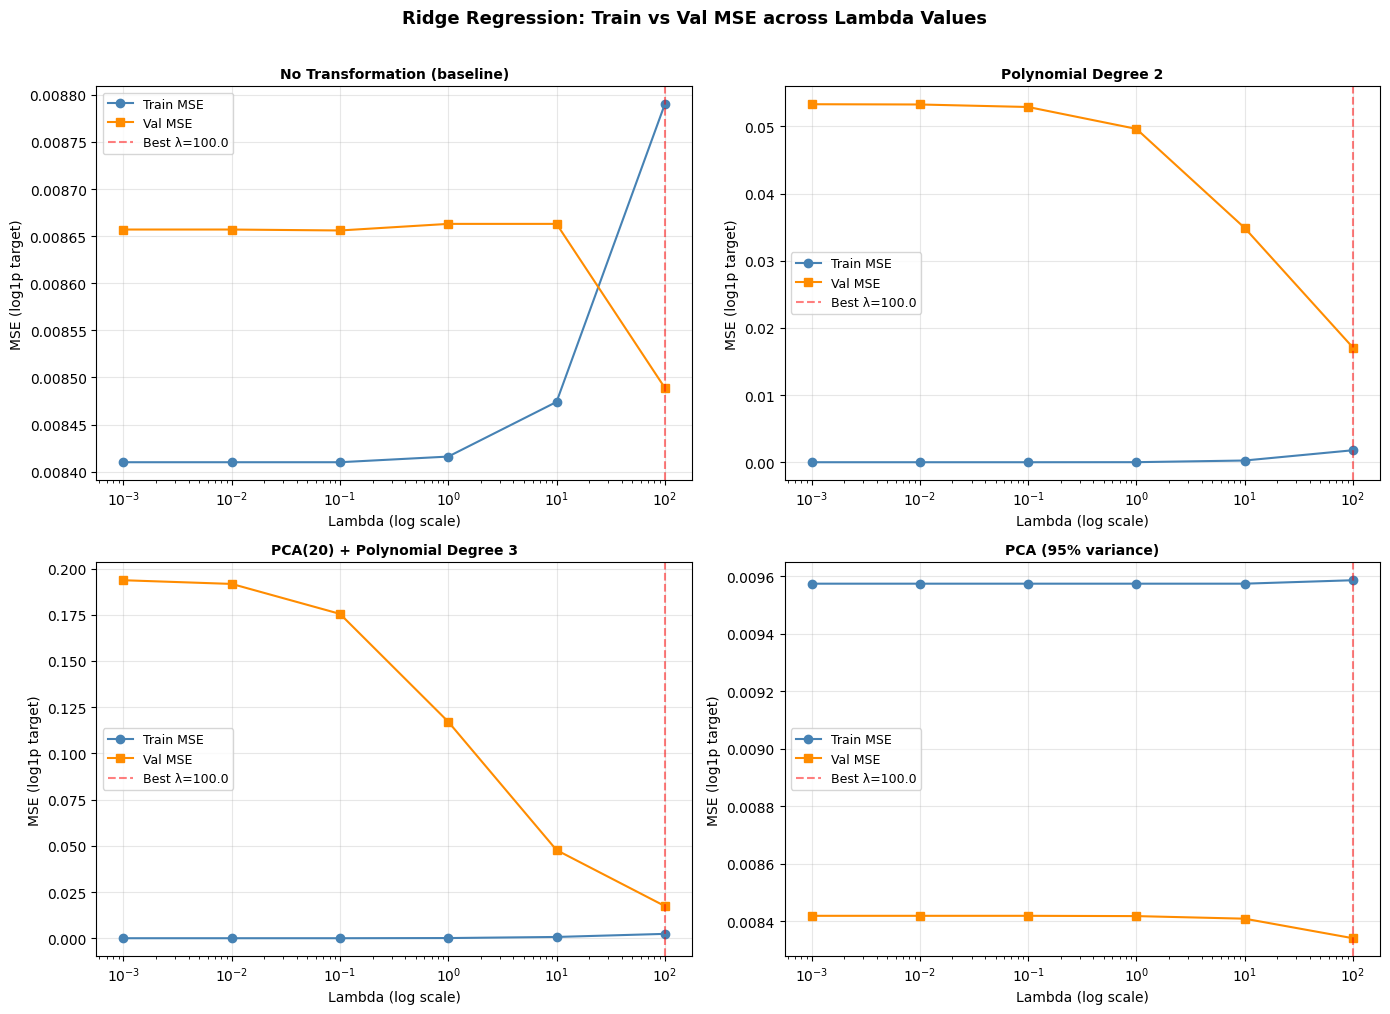

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for idx, fs in enumerate(ridge_feature_spaces):
    subset = ridge_df[ridge_df['Feature Space'] == fs['name']]
    ax = axes[idx]
    ax.semilogx(subset['Regularization'], subset['Train MSE'], 'o-', color='steelblue', label='Train MSE')
    ax.semilogx(subset['Regularization'], subset['Val MSE'],   's-', color='darkorange', label='Val MSE')
    best_lam = subset.loc[subset['Val MSE'].idxmin(), 'Regularization']
    ax.axvline(best_lam, color='red', linestyle='--', alpha=0.5, label=f'Best λ={best_lam}')
    ax.set_xlabel('Lambda (log scale)')
    ax.set_ylabel('MSE (log1p target)')
    ax.set_title(fs['name'], fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
plt.suptitle('Ridge Regression: Train vs Val MSE across Lambda Values', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

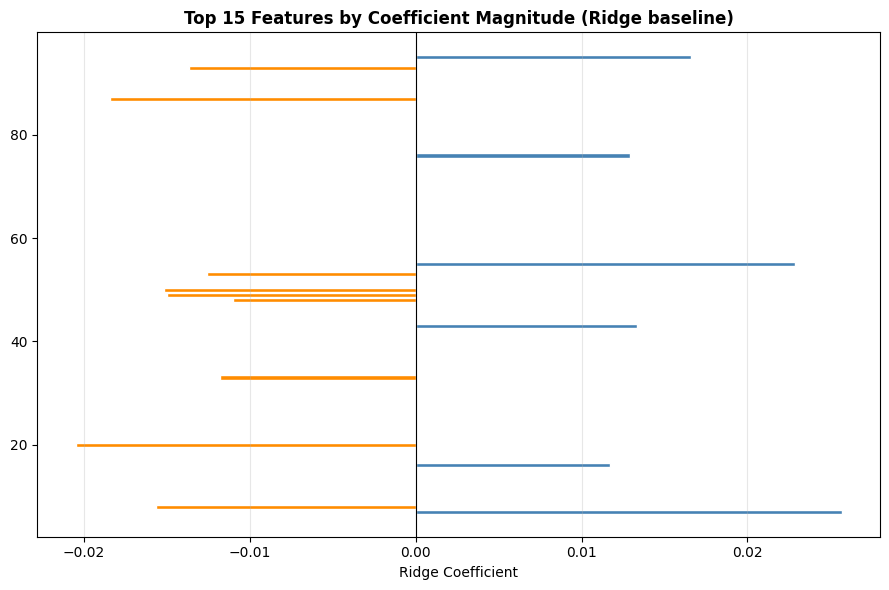

Blue = positive (higher feature → more crime)
Orange = negative (higher feature → less crime)


In [22]:
# Ridge coefficient analysis — best baseline model
try:
    feature_names = pd.read_csv('feature_names.csv', header=None)[0].tolist()
    best_baseline = ridge_best_models['no_transform'][0]
    coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': best_baseline.coef_})
    coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index).head(15)
    fig, ax = plt.subplots(figsize=(9, 6))
    colors = ['steelblue' if c > 0 else 'darkorange' for c in coef_df['Coefficient']]
    ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Ridge Coefficient')
    ax.set_title('Top 15 Features by Coefficient Magnitude (Ridge baseline)', fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    print("Blue = positive (higher feature → more crime)")
    print("Orange = negative (higher feature → less crime)")
except FileNotFoundError:
    print("feature_names.csv not found — skipping coefficient plot.")

---
# PART 2: Neural Network

### Transformation 1: Polynomial Degree 2
**Reasoning:** EDA scatter plots showed nonlinear relationships between several
features and the crime rate. Degree-2 features create all pairwise interaction
terms (x_i × x_j) and squared terms (x_i²), allowing the network to model
curved relationships without increasing network depth.

In [23]:
poly_nn = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_train_poly_nn = poly_nn.fit_transform(X_train)
X_val_poly_nn   = poly_nn.transform(X_val)
X_test_poly_nn  = poly_nn.transform(X_test)

scaler_poly_nn = StandardScaler()
X_train_poly_nn = scaler_poly_nn.fit_transform(X_train_poly_nn)
X_val_poly_nn   = scaler_poly_nn.transform(X_val_poly_nn)
X_test_poly_nn  = scaler_poly_nn.transform(X_test_poly_nn)

print(f"Poly degree-2 (NN): {X_train.shape[1]} → {X_train_poly_nn.shape[1]} features")

Poly degree-2 (NN): 100 → 5150 features


### Transformation 2: PCA (95% variance)
**Reasoning:** The dataset has ~100 features with known multicollinearity.
PCA decorrelates features and projects into independent principal components,
reducing noise and mitigating overfitting. Gives the network a cleaner,
lower-dimensional feature space to learn from.

PCA retained 34 components (95% variance)
Dimensionality: 100 → 34


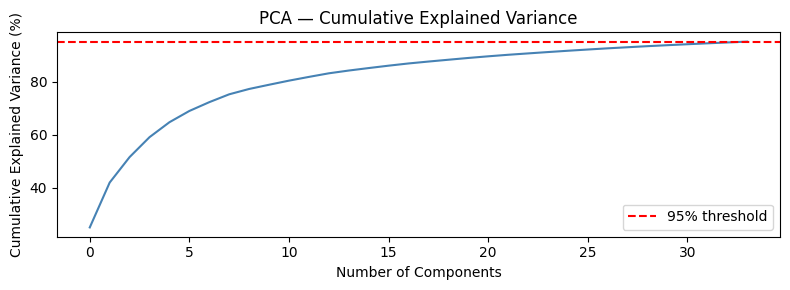

In [24]:
pca_nn = PCA(n_components=0.95, random_state=42)
X_train_pca_nn = pca_nn.fit_transform(X_train)
X_val_pca_nn   = pca_nn.transform(X_val)
X_test_pca_nn  = pca_nn.transform(X_test)

print(f"PCA retained {pca_nn.n_components_} components (95% variance)")
print(f"Dimensionality: {X_train.shape[1]} → {X_train_pca_nn.shape[1]}")

plt.figure(figsize=(8, 3))
plt.plot(np.cumsum(pca_nn.explained_variance_ratio_) * 100, color='steelblue')
plt.axhline(95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA — Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

### Transformation 3: K-Means Cluster Distances
**Reasoning:** Communities may naturally group based on socio-economic profiles
(e.g., high-income/low-crime vs. low-income/high-crime). Replacing features with
distances to k cluster centroids gives the network a soft cluster-membership
feature space — a nonlinear transformation that captures global structure.

In [25]:
N_CLUSTERS = 20
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
kmeans.fit(X_train)

X_train_km = pairwise_distances(X_train, kmeans.cluster_centers_)
X_val_km   = pairwise_distances(X_val,   kmeans.cluster_centers_)
X_test_km  = pairwise_distances(X_test,  kmeans.cluster_centers_)

scaler_km = StandardScaler()
X_train_km = scaler_km.fit_transform(X_train_km)
X_val_km   = scaler_km.transform(X_val_km)
X_test_km  = scaler_km.transform(X_test_km)

print(f"K-Means distances: {X_train.shape[1]} → {X_train_km.shape[1]} features")

K-Means distances: 100 → 20 features


## 2.2 Neural Network Architecture & Helpers

In [26]:
def make_loaders(X_tr, y_tr, X_v, y_v, batch_size=64):
    train_ds = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
    )
    val_ds = TensorDataset(
        torch.tensor(X_v, dtype=torch.float32),
        torch.tensor(y_v, dtype=torch.float32).unsqueeze(1)
    )
    return (DataLoader(train_ds, batch_size=batch_size, shuffle=True),
            DataLoader(val_ds,   batch_size=batch_size, shuffle=False))


def build_model(input_dim, n_hidden_layers=2, hidden_size=128, dropout=0.2):
    """
    Fully-connected regression network.
    Baseline: 1 hidden layer (per assignment spec).
    Transformations: 2 hidden layers.
    """
    layers = []
    in_dim = input_dim
    for _ in range(n_hidden_layers):
        layers += [nn.Linear(in_dim, hidden_size), nn.BatchNorm1d(hidden_size),
                   nn.ReLU(), nn.Dropout(dropout)]
        in_dim      = hidden_size
        hidden_size = max(hidden_size // 2, 32)
    layers.append(nn.Linear(in_dim, 1))
    return nn.Sequential(*layers)


def train_model(model, train_loader, val_loader, weight_decay,
                epochs=200, lr=1e-3, patience=20):
    optimizer  = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion  = nn.MSELoss()
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=7, factor=0.5)
    best_val   = float('inf')
    best_state = None
    no_improve = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for Xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(Xb)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                val_loss += criterion(model(Xb), yb).item() * len(Xb)
        val_loss /= len(val_loader.dataset)
        scheduler.step(val_loss)

        if val_loss < best_val:
            best_val   = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        X_tr_t = train_loader.dataset.tensors[0]
        y_tr_t = train_loader.dataset.tensors[1].numpy().flatten()
        p_tr   = model(X_tr_t).numpy().flatten()
        X_v_t  = val_loader.dataset.tensors[0]
        y_v_t  = val_loader.dataset.tensors[1].numpy().flatten()
        p_v    = model(X_v_t).numpy().flatten()

    return mean_squared_error(y_tr_t, p_tr), mean_squared_error(y_v_t, p_v), r2_score(y_v_t, p_v), model


print("Helpers defined.")

Helpers defined.


## 2.3 Neural Network Training Loop

In [27]:
WEIGHT_DECAYS = [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]

y_train_f32 = y_train.astype(np.float32)
y_val_f32   = y_val.astype(np.float32)

nn_feature_spaces = [
    {"name": "No Transformation (baseline)",  "short": "no_transform",
     "X_train": X_train,        "X_val": X_val,        "X_test": X_test,
     "n_layers": 1, "hidden_size": 128},
    {"name": "Polynomial Degree 2",            "short": "poly2",
     "X_train": X_train_poly_nn, "X_val": X_val_poly_nn, "X_test": X_test_poly_nn,
     "n_layers": 2, "hidden_size": 256},
    {"name": "PCA (95% variance)",             "short": "pca",
     "X_train": X_train_pca_nn,  "X_val": X_val_pca_nn,  "X_test": X_test_pca_nn,
     "n_layers": 2, "hidden_size": 128},
    {"name": "K-Means Cluster Distances (k=20)", "short": "kmeans",
     "X_train": X_train_km,     "X_val": X_val_km,     "X_test": X_test_km,
     "n_layers": 2, "hidden_size": 64},
]

nn_results     = []
nn_best_models = {}

for fs in nn_feature_spaces:
    print(f"\n{'='*60}\nFeature space: {fs['name']} | dim={fs['X_train'].shape[1]}\n{'='*60}")
    train_loader, val_loader = make_loaders(fs['X_train'], y_train_f32, fs['X_val'], y_val_f32)
    best_val_mse  = float('inf')
    best_model_fs = None

    for wd in WEIGHT_DECAYS:
        torch.manual_seed(42)
        model = build_model(fs['X_train'].shape[1], fs['n_layers'], fs['hidden_size'])
        tr_mse, v_mse, v_r2, trained = train_model(model, train_loader, val_loader, wd)
        gap = v_mse - tr_mse

        # Inline reasoning based on observed train/val behavior
        if wd == 0.0:
            reasoning = "No regularization — baseline to observe raw overfitting behavior."
        elif v_mse < best_val_mse and gap > 0.01:
            reasoning = f"Val MSE improved; gap={gap:.4f} shows overfitting — weight decay helping."
        elif v_mse < best_val_mse:
            reasoning = f"Val MSE improved (gap={gap:.4f}) — regularization still beneficial."
        elif gap < 0.002:
            reasoning = f"Val MSE worsening; gap={gap:.4f} is small — possible underfitting."
        else:
            reasoning = f"Val MSE worsening (gap={gap:.4f}) — weight decay={wd} too strong."

        print(f"  wd={wd:.0e} | Train={tr_mse:.4f}  Val={v_mse:.4f}  R²={v_r2:.3f}")
        print(f"         → {reasoning}")

        nn_results.append({
            "Model": "Neural Network", "Feature Space": fs['name'],
            "Regularization": wd, "Reg Type": "weight decay",
            "Train MSE": round(tr_mse, 5), "Val MSE": round(v_mse, 5),
            "Val R²": round(v_r2, 4), "Train/Val Gap": round(gap, 5),
            "Reasoning": reasoning
        })
        if v_mse < best_val_mse:
            best_val_mse  = v_mse
            best_model_fs = trained

    nn_best_models[fs['short']] = (best_model_fs, fs['X_test'], fs['name'])

print("\n Neural Network complete.")


Feature space: No Transformation (baseline) | dim=100
  wd=0e+00 | Train=0.0068  Val=0.0087  R²=0.675
         → No regularization — baseline to observe raw overfitting behavior.
  wd=1e-04 | Train=0.0068  Val=0.0087  R²=0.677
         → Val MSE improved (gap=0.0019) — regularization still beneficial.
  wd=1e-03 | Train=0.0069  Val=0.0086  R²=0.680
         → Val MSE improved (gap=0.0017) — regularization still beneficial.
  wd=1e-02 | Train=0.0068  Val=0.0086  R²=0.678
         → Val MSE worsening; gap=0.0018 is small — possible underfitting.
  wd=1e-01 | Train=0.0083  Val=0.0086  R²=0.681
         → Val MSE improved (gap=0.0002) — regularization still beneficial.
  wd=1e+00 | Train=0.0108  Val=0.0091  R²=0.662
         → Val MSE worsening; gap=-0.0017 is small — possible underfitting.

Feature space: Polynomial Degree 2 | dim=5150
  wd=0e+00 | Train=0.0045  Val=0.0094  R²=0.650
         → No regularization — baseline to observe raw overfitting behavior.
  wd=1e-04 | Train=0.0036  Va

## 2.4 Neural Network Results Table

In [42]:
nn_df = pd.DataFrame(nn_results)
cols  = ['Feature Space', 'Regularization', 'Train MSE', 'Val MSE', 'Val R²', 'Train/Val Gap']
print("=== NEURAL NETWORK: FULL RESULTS ===")
print(nn_df[cols].to_string(index=False))
print("\n=== NEURAL NETWORK: BEST PER FEATURE SPACE ===")
print(nn_df.loc[nn_df.groupby('Feature Space')['Val MSE'].idxmin()][cols].to_string(index=False))

=== NEURAL NETWORK: FULL RESULTS ===
                   Feature Space  Regularization  Train MSE  Val MSE   Val R²  Train/Val Gap
    No Transformation (baseline)        0.000000   0.006810 0.008710 0.675200       0.001910
    No Transformation (baseline)        0.000100   0.006800 0.008680 0.676600       0.001870
    No Transformation (baseline)        0.001000   0.006880 0.008600 0.679500       0.001720
    No Transformation (baseline)        0.010000   0.006810 0.008630 0.678200       0.001830
    No Transformation (baseline)        0.100000   0.008320 0.008550 0.681300       0.000230
    No Transformation (baseline)        1.000000   0.010810 0.009070 0.662100      -0.001740
             Polynomial Degree 2        0.000000   0.004540 0.009390 0.650100       0.004850
             Polynomial Degree 2        0.000100   0.003570 0.009240 0.655600       0.005670
             Polynomial Degree 2        0.001000   0.006750 0.009270 0.654600       0.002510
             Polynomial Degree 2 

## 2.5 Neural Network Plots

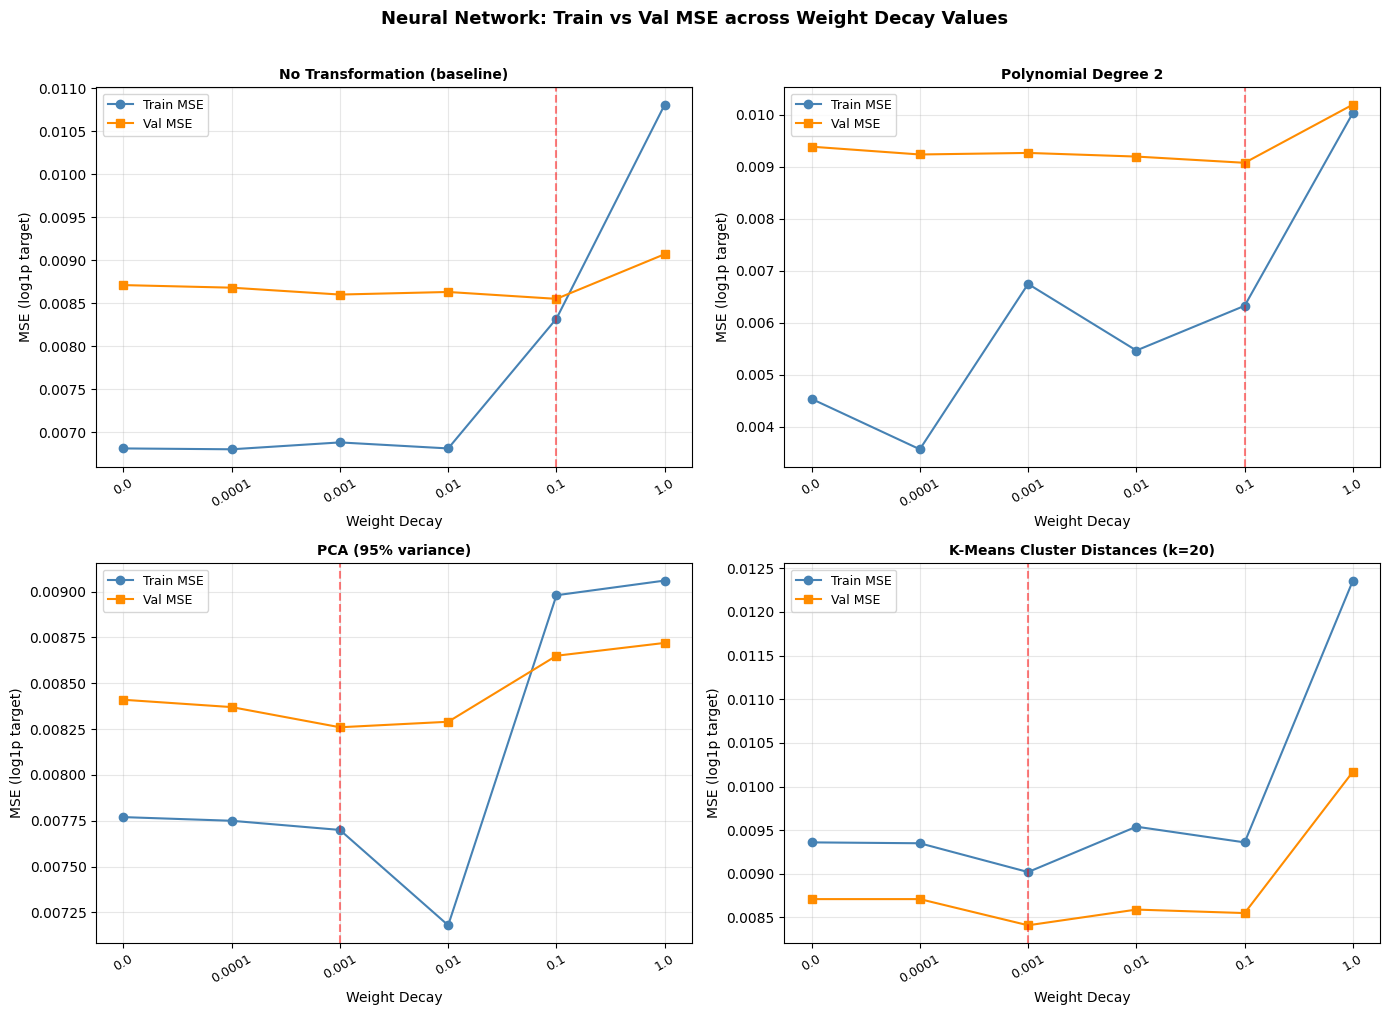

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for idx, fs in enumerate(nn_feature_spaces):
    subset = nn_df[nn_df['Feature Space'] == fs['name']]
    ax = axes[idx]
    ax.plot(range(len(WEIGHT_DECAYS)), subset['Train MSE'].values, 'o-', color='steelblue', label='Train MSE')
    ax.plot(range(len(WEIGHT_DECAYS)), subset['Val MSE'].values,   's-', color='darkorange', label='Val MSE')
    best_idx = subset['Val MSE'].values.argmin()
    ax.axvline(best_idx, color='red', linestyle='--', alpha=0.5)
    ax.set_xticks(range(len(WEIGHT_DECAYS)))
    ax.set_xticklabels([str(w) for w in WEIGHT_DECAYS], rotation=30, fontsize=9)
    ax.set_xlabel('Weight Decay')
    ax.set_ylabel('MSE (log1p target)')
    ax.set_title(fs['name'], fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
plt.suptitle('Neural Network: Train vs Val MSE across Weight Decay Values', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
# PART 3: K-Nearest Neighbors (KNN)

**Regularization:** k = 1, 3, 5, 10, 20, 50 (larger k = more smoothing = less overfitting)

**Feature spaces:** No transformation, Polynomial Degree 2, PCA (95% variance), K-Means Distances

In [30]:
from sklearn.cluster import KMeans

In [31]:
# creates feature transformations for KNN

feature_spaces = {}

# No transformation
feature_spaces["No Transformation"] = (
    X_train,
    X_val,
    X_test
)

# Polynomial Degree 2
# Creates extra nonlinear features, helps KNN see nonlinear relationships
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly2 = poly2.fit_transform(X_train)
X_val_poly2   = poly2.transform(X_val)
X_test_poly2  = poly2.transform(X_test)

# Re scale polynomial features because KNN depends on distance
poly_scaler = StandardScaler()
X_train_poly2 = poly_scaler.fit_transform(X_train_poly2)
X_val_poly2   = poly_scaler.transform(X_val_poly2)
X_test_poly2  = poly_scaler.transform(X_test_poly2)

feature_spaces["Polynomial Degree 2"] = (
    X_train_poly2,
    X_val_poly2,
    X_test_poly2
)

# pca keeping 95% variance
# reduces number of features in the data while keeping 95% of the variation
pca95 = PCA(n_components=0.95, random_state=42)
X_train_pca95 = pca95.fit_transform(X_train)
X_val_pca95   = pca95.transform(X_val)
X_test_pca95  = pca95.transform(X_test)

feature_spaces["PCA 95% Variance"] = (
    X_train_pca95,
    X_val_pca95,
    X_test_pca95
)

# k means distance representation
kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
kmeans.fit(X_train)

X_train_kmeans = kmeans.transform(X_train)
X_val_kmeans   = kmeans.transform(X_val)
X_test_kmeans  = kmeans.transform(X_test)

# scale distances for KNN
kmeans_scaler = StandardScaler()
X_train_kmeans = kmeans_scaler.fit_transform(X_train_kmeans)
X_val_kmeans   = kmeans_scaler.transform(X_val_kmeans)
X_test_kmeans  = kmeans_scaler.transform(X_test_kmeans)

feature_spaces["K-Means Distances k=20"] = (
    X_train_kmeans,
    X_val_kmeans,
    X_test_kmeans
)

In [46]:
#Train KNN on 6 hyperparameters

k_values = [1, 3, 5, 10, 20, 50]

knn_results = []

for feature_space_name, (Xtr, Xva, Xte) in feature_spaces.items():
    for k in k_values:
        model = KNeighborsRegressor(n_neighbors=k)

        model.fit(Xtr, y_train)

        train_pred = model.predict(Xtr)
        val_pred   = model.predict(Xva)

        train_mse = mean_squared_error(y_train, train_pred)
        val_mse   = mean_squared_error(y_val, val_pred)
        val_r2    = r2_score(y_val, val_pred)

        knn_results.append({
            "Model": "KNN",
            "Feature Space": feature_space_name,
            "k": k,
            "Regularization": k,
            "Reg Type": "k",
            "Train MSE": train_mse,
            "Val MSE": val_mse,
            "Val R²": val_r2
        })

knn_results_df = pd.DataFrame(knn_results)
knn_results_df

,Model,Feature Space,k,Regularization,Reg Type,Train MSE,Val MSE,Val R²
0,KNN,No Transformation,1,1,k,0.000000,0.018362,0.315639
1,KNN,No Transformation,3,3,k,0.005796,0.010504,0.608493
2,KNN,No Transformation,5,5,k,0.007436,0.009598,0.642279
3,KNN,No Transformation,10,10,k,0.009072,0.009363,0.651026
4,KNN,No Transformation,20,20,k,0.009986,0.009160,0.658585
5,KNN,No Transformation,50,50,k,0.011321,0.009556,0.643857
6,KNN,Polynomial Degree 2,1,1,k,0.000000,0.017572,0.345094
7,KNN,Polynomial Degree 2,3,3,k,0.006365,0.011050,0.588171
8,KNN,Polynomial Degree 2,5,5,k,0.008222,0.011228,0.581508
9,KNN,Polynomial Degree 2,10,10,k,0.010542,0.011441,0.573592


In [33]:
# Display results sorted by validation MSE

knn_results_df_sorted = knn_results_df.sort_values("Val MSE").reset_index(drop=True)
knn_results_df_sorted

,Model,Feature Space,k,Train MSE,Val MSE,Val R2
0,KNN,PCA 95% Variance,20,0.010032,0.009054,0.662539
1,KNN,No Transformation,20,0.009986,0.009160,0.658585
2,KNN,No Transformation,10,0.009072,0.009363,0.651026
3,KNN,PCA 95% Variance,10,0.009003,0.009449,0.647839
4,KNN,PCA 95% Variance,50,0.011400,0.009522,0.645114
5,KNN,No Transformation,50,0.011321,0.009556,0.643857
6,KNN,No Transformation,5,0.007436,0.009598,0.642279
7,KNN,PCA 95% Variance,5,0.007429,0.009803,0.634631
8,KNN,K-Means Distances k=20,20,0.010821,0.010023,0.626435
9,KNN,K-Means Distances k=20,10,0.009603,0.010394,0.612604


In [34]:
# best KNN model by validation MSE

best_knn_row = knn_results_df_sorted.iloc[0]
best_knn_row

Model                         KNN
Feature Space    PCA 95% Variance
k                              20
Train MSE                0.010032
Val MSE                  0.009054
Val R2                   0.662539
Name: 0, dtype: object

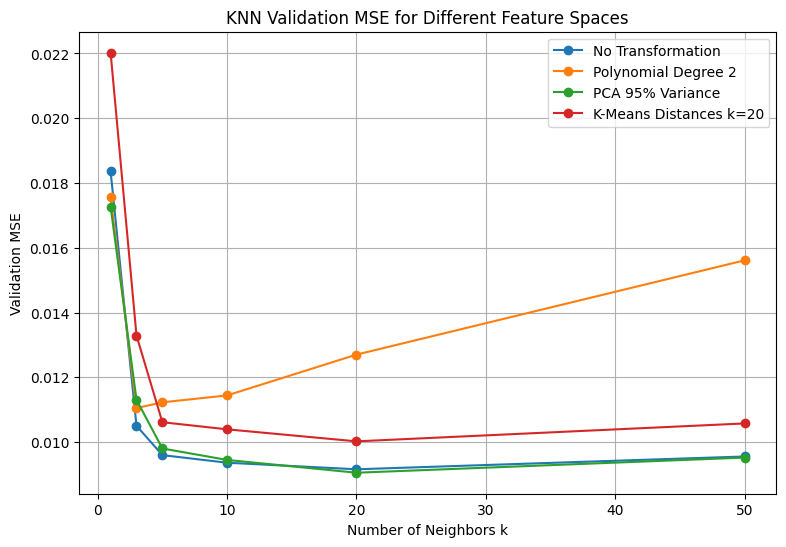

In [35]:
# plot validation MSE vs k for each feature space

plt.figure(figsize=(9, 6))

for feature_space_name in knn_results_df["Feature Space"].unique():
    subset = knn_results_df[knn_results_df["Feature Space"] == feature_space_name]
    plt.plot(subset["k"], subset["Val MSE"], marker="o", label=feature_space_name)

plt.xlabel("Number of Neighbors k")
plt.ylabel("Validation MSE")
plt.title("KNN Validation MSE for Different Feature Spaces")
plt.legend()
plt.grid(True)
plt.show()

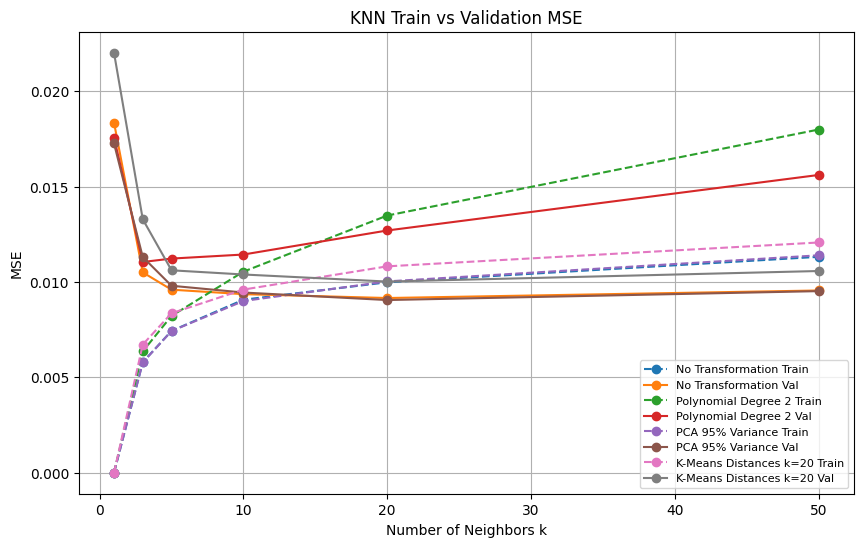

In [36]:
# train vs validation MSE

plt.figure(figsize=(10, 6))

for feature_space_name in knn_results_df["Feature Space"].unique():
    subset = knn_results_df[knn_results_df["Feature Space"] == feature_space_name]
    plt.plot(subset["k"], subset["Train MSE"], marker="o", linestyle="--", label=f"{feature_space_name} Train")
    plt.plot(subset["k"], subset["Val MSE"], marker="o", label=f"{feature_space_name} Val")

plt.xlabel("Number of Neighbors k")
plt.ylabel("MSE")
plt.title("KNN Train vs Validation MSE")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

In [37]:
# evalute best KNN model (PCA 95% variance with K=20) on the test set

best_feature_space = best_knn_row["Feature Space"]
best_k = int(best_knn_row["k"])

Xtr, Xva, Xte = feature_spaces[best_feature_space]

best_knn_model = KNeighborsRegressor(n_neighbors=best_k)
best_knn_model.fit(Xtr, y_train)

test_pred_log = best_knn_model.predict(Xte)

test_mse = mean_squared_error(y_test, test_pred_log)
test_r2 = r2_score(y_test, test_pred_log)

print("Best KNN Feature Space:", best_feature_space)
print("Best k:", best_k)
print("Test MSE:", test_mse)
print("Test R2:", test_r2)

Best KNN Feature Space: PCA 95% Variance
Best k: 20
Test MSE: 0.00946987992903675
Test R2: 0.6307771571322485


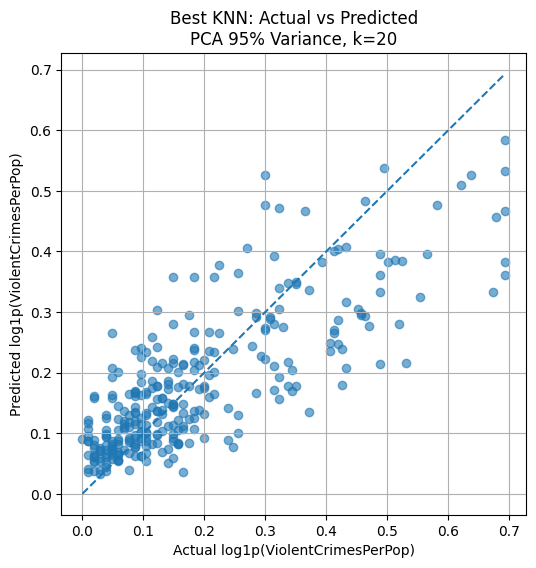

In [38]:
# actual vs predicted plot for best KNN model (PCA 95% variance with K=20)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_pred_log, alpha=0.6)

min_val = min(y_test.min(), test_pred_log.min())
max_val = max(y_test.max(), test_pred_log.max())

plt.plot([min_val, max_val], [min_val, max_val], "--")
plt.xlabel("Actual log1p(ViolentCrimesPerPop)")
plt.ylabel("Predicted log1p(ViolentCrimesPerPop)")
plt.title(f"Best KNN: Actual vs Predicted\n{best_feature_space}, k={best_k}")
plt.grid(True)
plt.show()

In [39]:
best_knn_summary = pd.DataFrame([{
    "Model": "KNN",
    "Feature Space": best_feature_space,
    "Best Reg.": f"k = {best_k}",
    "Train MSE": best_knn_row["Train MSE"],
    "Val MSE": best_knn_row["Val MSE"],
    "Val R2": best_knn_row["Val R2"],
    "Test MSE": test_mse,
    "Test R2": test_r2
}])

best_knn_summary

,Model,Feature Space,Best Reg.,Train MSE,Val MSE,Val R2,Test MSE,Test R2
0,KNN,PCA 95% Variance,k = 20,0.010032,0.009054,0.662539,0.009470,0.630777


---
# PART 4: Combined Comparison
Run after Parts 1, 2, and 3 are complete.

In [48]:
all_results = pd.DataFrame(ridge_results + nn_results + knn_results)

# Best val MSE per model + feature space
best_combined = all_results.loc[all_results.groupby(['Model', 'Feature Space'])['Val MSE'].idxmin()]
print("=== BEST VAL MSE: RIDGE vs NEURAL NETWORK ===")
print(best_combined[['Model', 'Feature Space', 'Regularization', 'Train MSE', 'Val MSE', 'Val R²']].to_string(index=False))

=== BEST VAL MSE: RIDGE vs NEURAL NETWORK ===
         Model                    Feature Space  Regularization  Train MSE  Val MSE   Val R²
           KNN           K-Means Distances k=20       20.000000   0.010821 0.010023 0.626435
           KNN                No Transformation       20.000000   0.009986 0.009160 0.658585
           KNN                 PCA 95% Variance       20.000000   0.010032 0.009054 0.662539
           KNN              Polynomial Degree 2        3.000000   0.006365 0.011050 0.588171
Neural Network K-Means Cluster Distances (k=20)        0.001000   0.009020 0.008410 0.686500
Neural Network     No Transformation (baseline)        0.100000   0.008320 0.008550 0.681300
Neural Network               PCA (95% variance)        0.001000   0.007700 0.008260 0.692100
Neural Network              Polynomial Degree 2        0.100000   0.006330 0.009080 0.661600
         Ridge     No Transformation (baseline)      100.000000   0.008790 0.008489 0.683600
         Ridge          

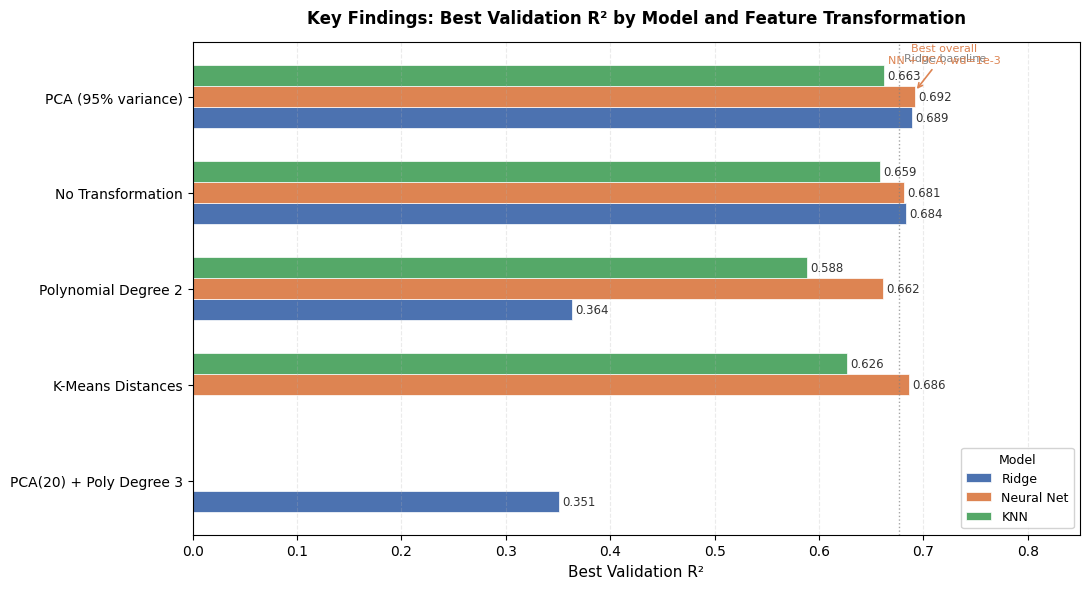

Figure 11: Key Findings chart — place this in Section E of the write-up.


In [ ]:
# Figure 11: Key Findings — Best Validation R² Across All Models and Feature Spaces
# This chart summarizes the central conclusion of the project:
# PCA generalizes best across all three models; polynomial features consistently hurt performance.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Pull best val R² per model + feature space from all results
all_best = all_results.loc[all_results.groupby(['Model', 'Feature Space'])['Val R²'].idxmax()].copy()

# Define a consistent feature space order and display labels
fs_order = [
    'No Transformation (baseline)',
    'Polynomial Degree 2',
    'PCA (95% variance)',
    'K-Means Cluster Distances (k=20)',
    'PCA(20) + Polynomial Degree 3',
    'K-Means Distances k=20',
    'No Transformation',
    'PCA 95% Variance',
    'Polynomial Degree 2',
]

# Normalise feature space names so all three models share the same labels
name_map = {
    'No Transformation (baseline)':      'No Transformation',
    'No Transformation':                  'No Transformation',
    'Polynomial Degree 2':               'Polynomial Degree 2',
    'PCA (95% variance)':                'PCA (95% variance)',
    'PCA 95% Variance':                  'PCA (95% variance)',
    'K-Means Cluster Distances (k=20)':  'K-Means Distances',
    'K-Means Distances k=20':            'K-Means Distances',
    'PCA(20) + Polynomial Degree 3':     'PCA(20) + Poly Degree 3',
}
all_best['FS_clean'] = all_best['Feature Space'].map(name_map).fillna(all_best['Feature Space'])
all_best['Model_clean'] = all_best['Model'].replace({'Neural Network': 'Neural Net'})

# Ordered feature spaces for y-axis (best at bottom for horizontal bar)
ordered_fs = [
    'PCA(20) + Poly Degree 3',
    'K-Means Distances',
    'Polynomial Degree 2',
    'No Transformation',
    'PCA (95% variance)',
]

models     = ['Ridge', 'Neural Net', 'KNN']
model_colors = {'Ridge': '#4C72B0', 'Neural Net': '#DD8452', 'KNN': '#55A868'}
n_fs    = len(ordered_fs)
n_mod   = len(models)
bar_h   = 0.22
y_pos   = np.arange(n_fs)

fig, ax = plt.subplots(figsize=(11, 6))

for m_idx, model in enumerate(models):
    subset = all_best[all_best['Model_clean'] == model].set_index('FS_clean')
    r2_vals = [subset.loc[fs, 'Val R²'] if fs in subset.index else 0 for fs in ordered_fs]
    offsets = (m_idx - (n_mod - 1) / 2) * bar_h
    bars = ax.barh(
        y_pos + offsets, r2_vals,
        height=bar_h,
        color=model_colors[model],
        edgecolor='white',
        linewidth=0.5,
        label=model
    )
    for bar, val in zip(bars, r2_vals):
        if val > 0:
            ax.text(
                bar.get_width() + 0.003,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}',
                va='center', ha='left', fontsize=8.5,
                color='#333333'
            )

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(ordered_fs, fontsize=10)
ax.set_xlabel('Best Validation R²', fontsize=11)
ax.set_title(
    'Key Findings: Best Validation R² by Model and Feature Transformation',
    fontsize=12, fontweight='bold', pad=14
)
ax.set_xlim(0, 0.85)
ax.axvline(0, color='black', linewidth=0.5)
ax.grid(True, axis='x', alpha=0.25, linestyle='--')

# Add a reference line at the best no-transform baseline (~0.677)
ax.axvline(0.677, color='gray', linewidth=1, linestyle=':', alpha=0.7)
ax.text(0.677 + 0.004, n_fs - 0.55, 'Ridge baseline', fontsize=8,
        color='gray', va='top')

# Annotation callout for best overall result
ax.annotate(
    'Best overall\nNN + PCA, wd=1e-3',
    xy=(0.692, y_pos[4] + bar_h * 0.25),
    xytext=(0.72, y_pos[4] + bar_h * 1.6),
    fontsize=8, color='#DD8452',
    arrowprops=dict(arrowstyle='->', color='#DD8452', lw=1.2),
    ha='center'
)

legend = ax.legend(
    title='Model', loc='lower right',
    fontsize=9, title_fontsize=9,
    framealpha=0.85
)

plt.tight_layout()
plt.show()


---
# Final Test Set Evaluation

In [50]:
final_test_results = []

# Ridge test evaluation
print('=== RIDGE: TEST SET ===')
for short, (model, X_te, name) in ridge_best_models.items():
    preds_log    = model.predict(X_te)
    test_mse     = mean_squared_error(y_test, preds_log)
    test_r2      = r2_score(y_test, preds_log)
    test_mse_raw = mean_squared_error(y_test_orig, inverse_log(preds_log))
    print(f'  {name:<40} MSE={test_mse:.5f}  R²={test_r2:.4f}')
    final_test_results.append({'Model': 'Ridge', 'Feature Space': name,
                                'Test MSE (log)': test_mse, 'Test MSE (orig)': test_mse_raw,
                                'Test R²': test_r2})

# Neural network test evaluation
print('\n=== NEURAL NETWORK: TEST SET ===')
for short, (model, X_te, name) in nn_best_models.items():
    model.eval()
    with torch.no_grad():
        preds_log = model(torch.tensor(X_te, dtype=torch.float32)).numpy().flatten()
    test_mse     = mean_squared_error(y_test, preds_log)
    test_r2      = r2_score(y_test, preds_log)
    test_mse_raw = mean_squared_error(y_test_orig, inverse_log(preds_log))
    print(f'  {name:<40} MSE={test_mse:.5f}  R²={test_r2:.4f}')
    final_test_results.append({'Model': 'Neural Network', 'Feature Space': name,
                                'Test MSE (log)': test_mse, 'Test MSE (orig)': test_mse_raw,
                                'Test R²': test_r2})

# KNN test evaluation
print('\n=== KNN: TEST SET ===')
Xtr_best, Xva_best, Xte_best = feature_spaces[best_feature_space]
knn_test_pred = best_knn_model.predict(Xte_best)
knn_test_mse  = mean_squared_error(y_test, knn_test_pred)
knn_test_r2   = r2_score(y_test, knn_test_pred)
knn_test_mse_raw = mean_squared_error(y_test_orig, np.expm1(knn_test_pred))
print(f'  {best_feature_space:<40} k={best_k}  MSE={knn_test_mse:.5f}  R²={knn_test_r2:.4f}')
final_test_results.append({'Model': 'KNN', 'Feature Space': best_feature_space,
                            'Test MSE (log)': knn_test_mse, 'Test MSE (orig)': knn_test_mse_raw,
                            'Test R²': knn_test_r2})

print('\n=== FINAL TEST SUMMARY ===')
print(pd.DataFrame(final_test_results).to_string(index=False))

=== RIDGE: TEST SET ===
  No Transformation (baseline)             MSE=0.00911  R²=0.6447
  Polynomial Degree 2                      MSE=0.01433  R²=0.4414
  PCA(20) + Polynomial Degree 3            MSE=0.02123  R²=0.1723
  PCA (95% variance)                       MSE=0.00928  R²=0.6381

=== NEURAL NETWORK: TEST SET ===
  No Transformation (baseline)             MSE=0.00981  R²=0.6176
  Polynomial Degree 2                      MSE=0.00999  R²=0.6106
  PCA (95% variance)                       MSE=0.00891  R²=0.6525
  K-Means Cluster Distances (k=20)         MSE=0.00862  R²=0.6641

=== KNN: TEST SET ===
  PCA 95% Variance                         k=20  MSE=0.00947  R²=0.6308

=== FINAL TEST SUMMARY ===
         Model                    Feature Space  Test MSE (log)  Test MSE (orig)  Test R²
         Ridge     No Transformation (baseline)        0.009113         0.017644 0.644695
         Ridge              Polynomial Degree 2        0.014327         0.025345 0.441394
         Ridge    PCA